<a href="https://colab.research.google.com/github/hanbiphyun/ESSA_YB/blob/main/ESAA_OB_week6_1_%EB%94%A5%EB%9F%AC%EB%8B%9D_%ED%95%84%EC%82%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###<딥러닝 파이토치 교과서>
p.138-163

##4장 딥러닝 시작

####4.1 인공 신경망의 한계와 딥러닝 출현
- 퍼센트론 : 다수의 신호를 입력받아 하나의 신호를 출력하는 정보 전달 원리

1. AND 게이트
- 모든 입력이 1일때 작동
2. OR 게이트
- 입력에서 둘 중 하나만 1이거나 둘다 1일때 작동
3. XOR 게이트
- 입력 두 개 중 한 개만 1일때 작동
- 단층 퍼셉트론에서는 학습 불가능 -> 입력층과 출력층 사이에 하나 이상의 중간층 두어 학습 가능하도록 '다층 퍼셉트론' 고안
  - 은닉층 여러개 = 심층신경망

####4.2 딥러닝 구조
**4.2.1 딥러닝 용어**
1. 층
- 입력층
- 은닉층 : 입력 노드부터 입력값 받아 가중합 계산하고 이 값을 활성화함수에 적용하여 출력층에 전달함
- 출력층 : 신경망의 최종 결괏값 포함된 층

2. 가중치 : 노드와 노드 간 연결 강도
- 입력 값이 연산 결과에 미치는 영향력 조절

3. 바이어스 : 가중합에 더해주는 상수, 하나의 뉴런에서 활성화 함수를 거쳐 최종적으로 출력되는 값 조절

4. 가중합(전달 함수) : 가중치와 신호의 곱을 합한 것
- 노드의 가중합 계산되면 활성화 함수로 보냄

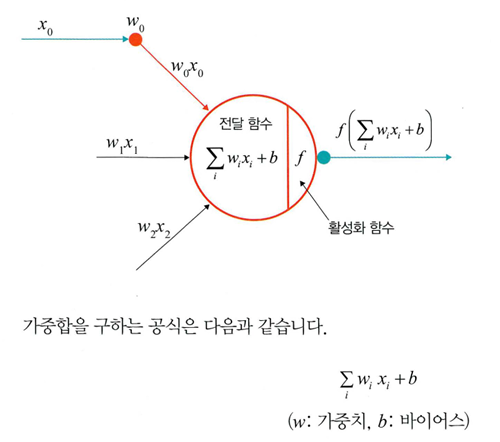


5. 함수
- 활성화 함수 : 전달 함수에서 받은 값을 출력할때 일정 기준에 따라 출력값 변화시키는 비선형 함수
  - 시그모이드 : 선형 함수의 결과를 0~1 사이의 비선형 형태로 변형해줌
    - 로지스틱 회귀 같은 분류 문제를 확률적으로 표현하는데 사용
    - 기울기 소실 문제 있음

  - 하이퍼볼릭 탄젠트 함수 : 선형 함수의 결과를 -1~1 사이 비선형 형태로 변형해줌
    - 시그모이드의 평균 편향 문제는 해결, 기울기 소실문제 있음
  - Leaky ReLU 함수 : 입력 값이 음수면 매우 작은 수 반환 -> 수렴 구간 제거됨
  - 소프트맥스 함수 : 입력 값을 0~1사이에 출력되도록 정규화하여 출력값 총합이 1이 되도록 함
    - 입력 신호 ak의 지수함수/ 모든 입력신호의 지수함수 합

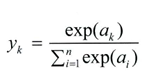


In [2]:
import torch

In [3]:
# 렐루 함수, 소프트맥스 함수 구현
class Net(torch.nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        #은닉층
        self.hidden = torch.nn.Linear(n_feature, n_hidden)
        self.relu= torch.nn.ReLu(inplace=True)
        #출력층
        self.out= torch.nn.Linear(n_hidden, n_output)
        self.softmax = torch.nn.Softmax(dim= n_output)

    def forward(self, x):
        x= self.hidden(x)
        # 은닉층을 위한 렐루 활성화 함수
        x= self.relu(x)
        x= self.out(x)
        # 출력층을 위한 소프트맥스 활성화 함수
        x= self.softmax(x)
        return x

- 경사하강법 : 학습률과 손실함수의 순간기울기를 이용해 가중치를 업데이트한다.
  - 미분의 기울기를 이용해 오차를 비교하고 최소화하는 방향으로 이동

- 손실 함수 : 가중치 학습을 위해 출력 함수의 결과와 실제 값 간의 오차 측정
  - 학습을 통해 얻은 데이터의 추정치가 실제 데이터와 얼마나 차이나는지 평가하는 지표
  - MSE : 실제 값과 예측값의 차이를 제곱해서 평균낸것
    
  - CEE : 분류 문제에서 원핫 인코딩했을때 사용할 수 있는 오차 계산법
    - 두개의 확률 분포 차이를 이용해서 시그모이드의 영향을 덜 받음
    - MSE보다 학습속도 빠름

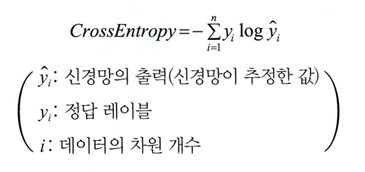

In [ ]:
# MSE
# import torch

# loss_fn= torch.nn.MSELoss(reduction='sum')
# y_pred= model(x)
# loss= loss_fn(y_pred, y)

In [ ]:
# CEE 크로스 엔트로피 에러
# loss= nn.CrossEntropyLoss()
# input= torch.randn(5,6, requires_grad=True)

# # torch.empty는 dtype torch.float32의 랜덤 값으로 채워진 텐서 반환
# target= torch.empty(3, dtype=torch.long).random_(5)
# output= loss(input, target)
# output.backward()

**4.2.2 딥러닝 학습**
-> 순전파 & 역전파
1. feedforward : 네트워크에 훈련데이터 들어올때 발생
- 데이터 기반으로 예측값 계산하기 위해 전체 신경망 교차해서 지나간다.
- 데이터가 모든 층 통과하고 모든 뉴런이 계산 완료 시 그 예측값은 출력층에 도달한다.

2. 역전파
- 손실함수로 네트워크의 예측값과 실제 값의 차이 추정할때 손실 함수 비용이 0에 가깝도록 가중치를 조정한다.
- 손실 계산되면 정보가 역으로 (출력->은닉->입력층) 전파되는 과정을 거친다. = 역전파
  - 은닉층의 뉴런은 각 뉴런이 원래 출력에 대한 가중치에 따라 값이 다르다. -> 예측값과 실제값 차이를 각 뉴런의 가중치로 미분한 후 기존 가중치에서 뺀다.
- 모든 뉴런에 대해 진행해 계산된 뉴런 결과를 다시 순전파의 가중치값으로 사용한다.




**4.2.3 딥러닝의 문제점과 해결방안**
1. 과적합 문제 발생
- 해결 방안
  1) 드롭아웃 : 학습 과정 중 임의로 일부 노드들을 학습에서 제외시킴

2. 기울기 소멸 문제 발생
: 출력층에서 은닉층으로 전달되는 오차가 크게 줄어들어 학습되지 않는 현상

: 학습 양이 0에 가까워져 학습이 더뎌지고 오차를 줄이지 못 한채로 수렴함
- 해결방안 : 렐루 활성화 함수 사용

3. 성능 나빠지는 문제 발생
: 경사 하강법이 손실 함수의 비용이 최소되는 지점찾을때까지 기울기 낮은쪽으로 이동시키는 과정 반복
- 배치 경사 하강법 : 전체 데이터셋에 대한 오류를 구한 후 기울기를 한번만 계산해서 모델 파라미터 업데이트, 전체 훈련 데이터셋에 대해 가중치 편미분함
  - 학습 오래걸림
- 해결 방안
  1) 확률적 경사 하강법 : 임의로 선택한 데이터에 대해 기울기 계산
  - 속도 빠름

  2) 미니 배치 경사하강법 : 미니 배치 한개마다 기울기를 구한 후 평균 기울기 이용해 모델 업데이트해서 학습하는 방법
  - 빠르고 안정적

In [5]:
class DropoutModel(torch.nn.Module):
    def __init__(self):
        super(DropoutModel, self).__init__()
        self.layer1= torch.nn.Linear(784, 1200)
        self.dropout1= torch.nn.Dropout(0.5)
        self.layer2= torch.nn.Linear(1200,1200)
        self.dropout2= torch.nn.Dropout(0.5)
        self.layer3= torch.nn.Linear(1200, 10)

    def forward(self, x):
        x= F.relu(self.layer1(x))
        x= self.dropout1(x)
        x= F.relu(self.layer2(x))
        x= self.dropout2(x)
        return self.layer3(x)

In [ ]:
# # 미니배치 구현
# class CustomDataset(Dataset):
#     def __init__(self):
#         self.x_data= [[1,2,3],[4,5,6],[7,8,9]]
#         self.y_data= [[12],[18],[11]]

#         def __len__(self):
#             return len(self.x_data)
#         def __getitem__(self, idx):
#             x= torch.FloatTensor(self.x_data[idx])
#             y= torch.FloatTensor(self.y_data[idx])
#             return x, y
# dataset= CustomDataset()
# dataloader= DataLoader(
#     dataset,
#     batch_size=2,
#     # 데이터 불러올때마다 랜덤으로 섞어서 가져옴
#     shuffle=True
# )

**옵티마이저**
: 확률적 경사 하강법의 파라미터 변경 폭이 불안정한 문제 해결하기 위해 학습속도와 운동량 조정한다.
- 속도개선
  - Adagrad: 변수 업데이트 횟수에 따라 학습률 조정-> 많이 변화하는 변수는 학습률 작게하여 오차값 줄이고자함
    - 기울기 0에 수렴하는 문제가 있어서 대신 RMSProp사용
  ```
  optimizer= torch.optim.Adagrad(model.parameters(), lr=0.01)
  ```
  - Adadelta : 아다그라드에서 기울기 크기 누적값(G)이 커지면 학습 멈추는 문제 해결하기 위함
    - 학습률에 대한 하이퍼파라미터 필요하지않음
  ```
  optimizer= torch.optim.Adadelta(model.parameters(), lr=1.0)
  ```
  - RMSProp : 아다그라드의 G(기울기 크기 누적값)이 무한히 커지는 것 방지하고자 제안
    - 감마 추가하여 사용자가 학습률 크기를 비율로 조정할수있도록 했다
  ```
  optimizer= torch.optim.RMSProp(model.parameters(), lr=0.01)
  ```
  
- 운동량 개선
  - 모멘텀 : 가중치 수정전에 이전 수정방향과 같은 방향으로 일정 비율만 수정하는 방법
    - SGD와 같이 사용
    - 아래는 0.9에서 조금씩 증가시키며 사용하는 경우이다.
```
optimizer= torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
```
  - 네스테로프 모멘텀(NAG) : 모멘텀값과 기울기 값이 더해져 실제 값을 만드는 기존 모멘텀과 달리 모멘텀값이 적용된 지점에서 기울기값 계산 -> 빠른 속도 + 적절한 제동
  ```
  optimizer= torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, nesterov=True)
```
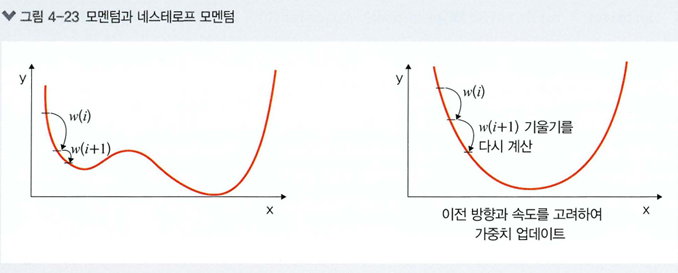


- 둘다 개선 : 아담 -> 알엠에스프롭특징인 기울기의 제곱을 지수평균한 값과 모멘텀특징인 감마를 수식에 활용
```
optimizer= torch.optim.Adam(model.parameters(), lr=0.1)
```

**딥러닝을 사용할 때 이점**
1. 특성추출 : 데이터의 특징을 찾아내고 데이터를 벡터로 변환하는 작업
- 빅데이터로 다양한 사례를 이용해 성능 향상 시킴

### 4.3 딥러닝 알고리즘
- 합성곱 신경망
- 순환 신경망
- 제한된 볼츠만 머신(RBM)
- 심층 신뢰 신경망(DBN)

**4.3.1 심층 신경망 DNN**
: 다수의 은닉층을 포함하는 인공신경망
- 연산량, 기울기 소멸문제 해결하고자 드롭아웃, 렐루, 배치정규화 필요

**4.3.2 합성곱 신경망 CNN**
: 합성곱층, 풀링층 포함하는 이미지 처리 성능이 좋은 인공신경망 알고리즘
- LeNet-5, AlexNet
- 더 깊은 신경망 -> VGG, GoogLeNet, ResNet
- 차별성
  - 각 층의 입출력형상 유지
  - 이미지 공간 정보 유지하면서 인접 이미지와 차이 있는 특징 인식
  - 복수 필터로 이미지의 특징 추출하고 학습
  - 추출한 이미지의 특징 모으고 강화하는 풀링층 존재
  - 필터를 공유 파라미터로 사용하여 학습파라미터가 적음

**4.3.3 순환신경망**
: 시계열 데이터 같은 시간흐름에 따라 변화하는 데이터를 학습하기위한 인공신경망
- 특징
  - 시간성 가진 데이터 많음
  - 데이터가 동적이고 길이가 가변적
  - 매우 긴 데이터를 처리하는 연구 많음
- 문제 : 기울기 소멸 문제 -> 메모리 개념 도입한 LSTM 사용
- 언어 모델링, 텍스트 생성, 음성 인식 등

**4.3.4 제한된 볼츠만 머신**
: 가시층과 은닉층으로 구성된 모델
- 특징
  - 차원감소, 분류, 선형 회귀분석, 협업필터링 등에 사용
  - 심층 신뢰 신경망의 요소

**4.3.5 심층 신뢰 신경망**
: 입력층과 은닉층으로 구성된 제한된 볼츠만 머신을 여러층으로 쌓은 형태로 연결된 신경망, 비지도 학습 가능
- 학습 절차
1. 가시층과 은닉층 1에 제한된 볼츠만 머신을 사전 훈련
2. 첫번째 층 입력데이터와 파라미터를 고정하여 두번째 제한된 볼츠만머신을 사전훈련
3. 원하는 층개수만큼 쌓아올려 전체 DBN완성